<a href="https://colab.research.google.com/github/Maagiio/NLP/blob/master/04_Optimizers_Activations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 04: Optimizers & Activation Functions

In this exercise you investigate two fundamental design choices in training
neural networks: **optimization algorithms** and **activation functions**.

You first gain an intuitive understanding of how different optimizers navigate
a loss landscape on a 2-D test function, then measure their practical effect
on MNIST digit classification.

**Learning objectives**
- Implement SGD and SGD with momentum from scratch
- Use PyTorch's autograd to run adaptive optimizers (RMSprop, Adam)
- Understand visually how momentum and adaptive learning rates change optimizer
  behaviour
- Observe how activation function choice affects convergence speed and depth
- Compare optimizer performance on a realistic classification task

**Total points: 152**
- Section 1: Loss Landscape Visualisation (62 pts)
- Section 2: Activation Functions on MNIST (40 pts)
- Section 3: Comparing Optimizers on MNIST (50 pts)


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader


---
## Section 1: Loss Landscape Visualisation with Optimizers (62 pts)

### Background

The **Beale function** is a standard 2-D optimisation test function with a
narrow, curved valley and a global minimum at **(3, 0.5)** where f = 0.
It is a useful benchmark because different optimisers show visually distinct
trajectories: SGD crawls along the valley floor, momentum overshoots, and
Adam finds the minimum quickly.

You will implement the two manual optimisers from scratch, wrap a PyTorch
optimiser with autograd, run all four from the same starting point,
and then analyse the results.


In [2]:
# -- Provided: Beale function and gradient -----------------------------------
# Global minimum at (3, 0.5); domain: x, y in [-4.5, 4.5]
# beale() uses only +, -, *, ** and is autograd-compatible:
# it works with NumPy arrays (contour plots) and torch Tensors (autograd).

def beale(x, y):
    """Beale function. Works on NumPy scalars/arrays and torch Tensors."""
    t1 = 1.5   - x + x * y
    t2 = 2.25  - x + x * y**2
    t3 = 2.625 - x + x * y**3
    return t1**2 + t2**2 + t3**2


def beale_grad(x, y):
    """Analytical gradient of the Beale function (NumPy scalars)."""
    t1 = 1.5   - x + x * y
    t2 = 2.25  - x + x * y**2
    t3 = 2.625 - x + x * y**3
    df_dx = (2*t1*(-1 + y)
             + 2*t2*(-1 + y**2)
             + 2*t3*(-1 + y**3))
    df_dy = (2*t1*(x)
             + 2*t2*(2*x*y)
             + 2*t3*(3*x*y**2))
    return df_dx, df_dy


In [3]:
# -- Provided: visualisation helpers ----------------------------------------

def plot_contour_trajectories(paths_dict, x_start, y_start,
                               title="Optimizer Trajectories on Beale Function"):
    """
    Plot optimizer trajectories overlaid on a contour map of the Beale function.

    Parameters
    ----------
    paths_dict : dict  {name: list of (x, y) tuples}
    x_start, y_start : float  (used only for the title annotation)
    title : str
    """
    xv = np.linspace(-4.5, 4.5, 300)
    yv = np.linspace(-4.5, 4.5, 300)
    X, Y = np.meshgrid(xv, yv)
    Z = beale(X, Y)

    fig, ax = plt.subplots(figsize=(10, 8))
    cp = ax.contourf(X, Y, np.log1p(Z), levels=40, cmap="viridis", alpha=0.85)
    fig.colorbar(cp, ax=ax, label="log(1 + f(x, y))")

    colors = ["red", "cyan", "lime", "orange"]
    for (name, path), color in zip(paths_dict.items(), colors):
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, "-", color=color, linewidth=1.5, label=name)
        ax.plot(xs[0],  ys[0],  "o", color=color, markersize=9,
                label=f"{name} start")
        ax.plot(xs[-1], ys[-1], "s", color=color, markersize=9)

    ax.plot(3.0, 0.5, "w*", markersize=18, label="Global min (3, 0.5)",
            zorder=5)
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper left", fontsize=9, ncol=2)
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(losses_dict, title="Loss over Optimisation Steps"):
    """
    Plot loss-over-steps for multiple optimisers on a log scale.

    Parameters
    ----------
    losses_dict : dict  {name: list of float}
    title : str
    """
    plt.figure(figsize=(10, 5))
    colors = ["red", "cyan", "lime", "orange"]
    for (name, losses), color in zip(losses_dict.items(), colors):
        plt.plot(losses, color=color, linewidth=1.5, label=name)
    plt.xlabel("Step", fontsize=12)
    plt.ylabel("f(x, y)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.yscale("log")
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Task 1.1: Implement SGD and SGD with Momentum (12 pts)

Implement the two functions below **from scratch** using the update rules:

**Plain SGD**
$$\theta \leftarrow \theta - \alpha \, \nabla_{\theta} f$$

**SGD with Momentum**
$$v \leftarrow \mu\, v - \alpha \, \nabla_{\theta} f \qquad
  \theta \leftarrow \theta + v$$

where $\alpha$ is the learning rate and $\mu$ is the momentum coefficient.

Use `beale_grad(x, y)` to obtain the gradient $(g_x, g_y)$.


In [6]:
def run_sgd(x_init, y_init, lr=0.005, n_steps=300):
    """
    Run plain SGD on the Beale function.

    Parameters
    ----------
    x_init, y_init : float   Starting coordinates.
    lr             : float   Learning rate.
    n_steps        : int     Number of update steps.

    Returns
    -------
    path   : list of (x, y) tuples, one per step including the start
    losses : list of float, Beale function value at each step
    """
    x, y = float(x_init), float(y_init)
    path   = [(x, y)]
    losses = [beale(x, y)]

    for _ in range(n_steps):
        gx, gy = beale_grad(x, y)
        x = x-lr*gx
        y = y - lr * gy

        path.append((x, y))
        losses.append(beale(x, y))

    return path, losses


def run_sgd_momentum(x_init, y_init, lr=0.005, momentum=0.9, n_steps=300):
    """
    Run SGD with momentum on the Beale function.

    Parameters
    ----------
    x_init, y_init : float   Starting coordinates.
    lr             : float   Learning rate.
    momentum       : float   Momentum coefficient (typically 0.9).
    n_steps        : int     Number of update steps.

    Returns
    -------
    path   : list of (x, y) tuples
    losses : list of float
    """
    x, y   = float(x_init), float(y_init)
    vx, vy = 0.0, 0.0          # velocity terms, initialised to zero
    path   = [(x, y)]
    losses = [beale(x, y)]

    for _ in range(n_steps):
        gx, gy = beale_grad(x, y)
        vx = momentum * vx - lr * gx
        vy = momentum * vy - lr * gy
        x = x + vx
        y = y + vy

        path.append((x, y))
        losses.append(beale(x, y))

    return path, losses


### Task 1.2: PyTorch Autograd Optimiser Wrapper (10 pts)

Implement `run_torch_optimizer` using PyTorch's autograd.
This lets you pass *any* `torch.optim.Optimizer` factory and you will use it
for **RMSprop** and **Adam**.

Because PyTorch optimizers need the parameter list at construction time, the
function accepts a **factory callable** `make_optimizer` that receives the
parameter list and returns an optimizer object. You will call it as:

```python
run_torch_optimizer(lambda p: torch.optim.Adam(p, lr=0.05), ...)
```

Steps inside the loop:
1. Call `optimizer.zero_grad()` to clear previous gradients.
2. Compute `loss = beale(x, y)` (works directly with torch Tensors).
3. Call `loss.backward()` to compute gradients via autograd.
4. Call `optimizer.step()` to update `x` and `y`.
5. Append `(x.item(), y.item())` to `path` and the loss value to `losses`.


In [7]:
def run_torch_optimizer(make_optimizer, x_init, y_init, n_steps=300):
    """
    Run a PyTorch optimiser on the Beale function via autograd.

    Parameters
    ----------
    make_optimizer : callable
        Factory that accepts a parameter list and returns an optimizer.
        Example: lambda p: torch.optim.Adam(p, lr=0.05)
    x_init, y_init : float   Starting coordinates.
    n_steps        : int     Number of update steps.

    Returns
    -------
    path   : list of (x, y) tuples, one per step including the start
    losses : list of float
    """
    # TODO:
    # 1. Create torch scalar tensors for x and y with requires_grad=True.
    # 2. Call make_optimizer([x, y]) to construct the optimizer.
    # 3. Loop n_steps times:
    #    a. optimizer.zero_grad()
    #    b. loss = beale(x, y)
    #    c. loss.backward()
    #    d. optimizer.step()
    #    e. Append (x.item(), y.item()) to path and loss.item() to losses.
    x = torch.tensor(x_init, requires_grad=True)
    y = torch.tensor(y_init, requires_grad=True)
    optimizer = make_optimizer([x, y])
    path   = [(x.item(), y.item())]
    losses = [beale(x, y).item()]
    for _ in range(n_steps):
      optimizer.zero_grad()
      loss = beale(x, y)
      loss.backward()
      optimizer.step()
      path.append((x.item(), y.item()))
      losses.append(loss.item())


    return path, losses


### Task 1.3: Run All Four Optimisers and Plot Trajectories (12 pts)

Run each of the four optimisers from the **same starting point** and collect
their paths and losses. Then use the provided helper functions to visualise:
1. the trajectories on a contour plot of the Beale function, and
2. the loss-over-steps curves on a log scale.

**Suggested hyperparameters** (feel free to experiment):
| Optimiser | lr | extra |
|---|---|---|
| SGD | 0.005 | - |
| SGD + Momentum | 0.005 | momentum=0.9 |
| RMSprop | `lambda p: torch.optim.RMSprop(p, lr=0.01)` | - |
| Adam | `lambda p: torch.optim.Adam(p, lr=0.05)` | - |

Use `n_steps=300` and start from `x_init=-1.0, y_init=-1.0`.


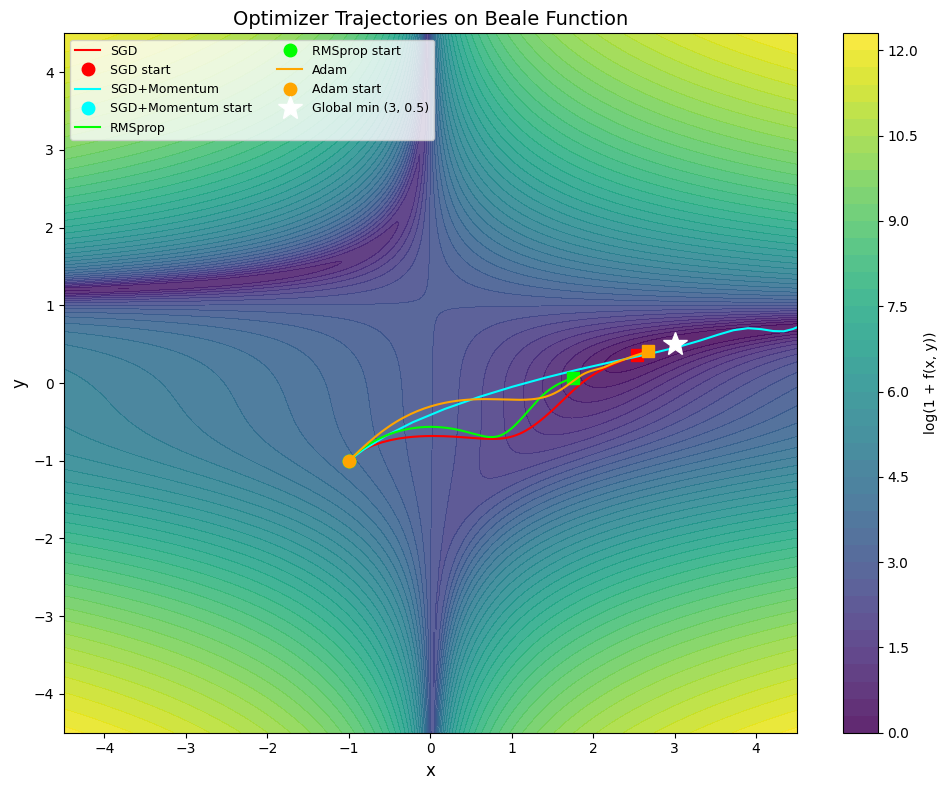

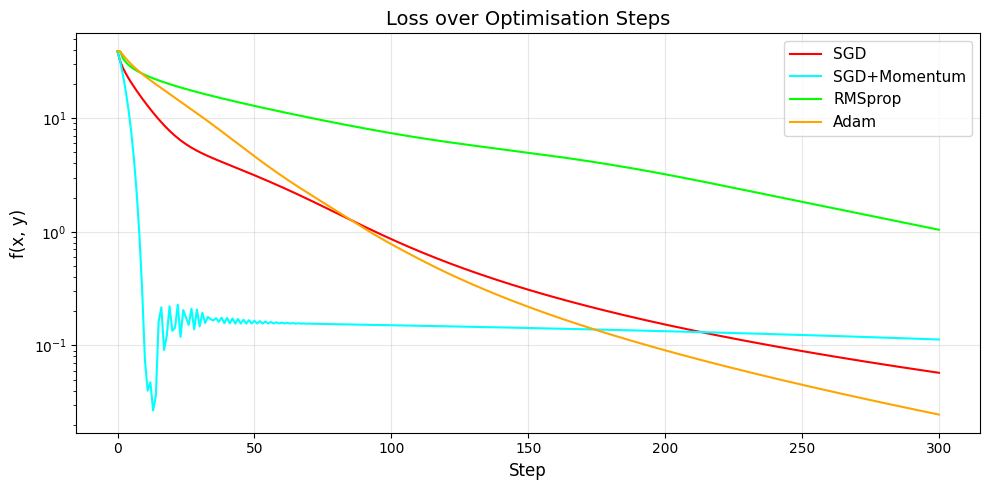

In [9]:
# TODO (12 pts): Run all four optimisers from the same starting point.
# Call run_sgd(), run_sgd_momentum(), and run_torch_optimizer() (twice).
# Collect paths and losses, then plot with the provided helpers.

### Your code here
x_init, y_init = -1.0, -1.0

path_sgd,      losses_sgd      = run_sgd(x_init, y_init)
path_momentum, losses_momentum = run_sgd_momentum(x_init, y_init)
path_rmsprop,  losses_rmsprop  = run_torch_optimizer(lambda p: torch.optim.RMSprop(p, lr=0.01), x_init, y_init)
path_adam,     losses_adam     = run_torch_optimizer(lambda p: torch.optim.Adam(p, lr=0.05), x_init, y_init)

paths_dict = {
    "SGD":          path_sgd,
    "SGD+Momentum": path_momentum,
    "RMSprop":      path_rmsprop,
    "Adam":         path_adam,
}
losses_dict = {
    "SGD":          losses_sgd,
    "SGD+Momentum": losses_momentum,
    "RMSprop":      losses_rmsprop,
    "Adam":         losses_adam,
}

plot_contour_trajectories(paths_dict, x_init, y_init)
plot_loss_curves(losses_dict)


In [10]:
# -- Provided: print final Beale loss for each optimizer --------------------
for name, losses in losses_dict.items():
    print(f"{name:20s} final loss: {losses[-1]:.6f}")


SGD                  final loss: 0.057306
SGD+Momentum         final loss: 0.112477
RMSprop              final loss: 1.041922
Adam                 final loss: 0.024563


### Task 1.4: Comparison Table and Analysis

#### Optimizer Comparison Table (8 pts)

Fill in the table. Use "Yes" / "No" for the first three rows.
For the last row, read the final loss values from the cell above.

| Property | SGD | SGD + Momentum | RMSprop | Adam |
|---|---|---|---|---|
| Uses accumulated past gradients (momentum) |No |Yes |Yes|Yes|
| Adapts learning rate per parameter |No |No |Yes | Yes|
| Requires only a single hyperparameter (lr) |Yes |no |no |no |
| Final Beale loss after 300 steps (from your run) |0.057306 |0.112477 |1.041922 | 0.024563 |

---

#### Analysis Questions (28 pts)

**Q1 (8 pts):** SGD makes slow, uniform steps, while Adam converges much faster.
What specific mechanism in Adam allows it to take larger effective steps in
directions with consistently small gradients?
Answer in 1-2 sentences.

Adam passt die Learning Rate pro Parameter an, indem es den quadratischen Durchschnitt vergangener Gradienten speichert. Bei konsistent kleinen Gradienten wird die effektive Learning Rate größer, was schnellere Konvergenz ermöglicht.

---

**Q2 (10 pts):** Compare the trajectory of plain SGD and SGD+Momentum on your
contour plot. Does momentum help the optimiser navigate the narrow valley of
the Beale function, or does it cause overshooting? Describe what you observe
in 1-2 sentences.

SGD+Momentum überschießt das Minimum der Beale Funktion stark und verlässt sogar den sichtbaren Bereich des Plots. Die akkumulierte Velocity wird zu groß für die schmale Kurve der Beale Funktion.

---

**Q3 (10 pts):** Adam is often described as "SGD with Momentum + RMSprop".
Looking at your comparison table, which rows show each of these two
contributions? Explain briefly what Momentum contributes and what RMSprop
contributes. (1-2 sentences)

Adam kombiniert Momentum, das vergangene Gradienten für die Richtung akkumuliert, mit RMSprop, das die Learning Rate pro Parameter anpasst. Zusammen ermöglicht das schnelle und stabile Konvergenz.


---
## Section 2: Activation Functions on MNIST (40 pts)

We now move to a real classification task.
You will compare the three activation functions **ReLU**, **Sigmoid**, and **Tanh**
on MNIST digit classification.

The optimiser (Adam) and all other hyperparameters are held constant; only the
activation function changes.

The helper functions `build_and_train`, `evaluate_model`, and
`plot_training_histories` are provided.


In [ ]:
# -- Provided: load and split MNIST ----------------------------------------
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist["data"].astype("float32") / 255.0
y = mnist["target"].astype("int64")

# 50 000 train / 10 000 val / 10 000 test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10_000, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=10_000, random_state=42,
    stratify=y_trainval)


def _make_loader(Xa, ya, batch_size=128, shuffle=False):
    ds = TensorDataset(torch.tensor(Xa, dtype=torch.float32),
                       torch.tensor(ya, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


train_loader = _make_loader(X_train, y_train, shuffle=True)
val_loader   = _make_loader(X_val,   y_val)
test_loader  = _make_loader(X_test,  y_test)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")


In [ ]:
# -- Provided: training and evaluation helpers ------------------------------

def evaluate_model(model, data_loader):
    """
    Evaluate model loss and accuracy on all batches in data_loader.

    Returns
    -------
    avg_loss : float
    accuracy : float
    """
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            total_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            correct    += (outputs.argmax(dim=1) == y_batch).sum().item()
            total      += y_batch.size(0)
    return total_loss / total, correct / total


def build_and_train(act_cls, epochs=10):
    """
    Build and train a shallow MLP on MNIST.

    Architecture: Linear(784, 64) + activation -> Linear(64, 10) raw logits
    Optimiser: Adam (lr=0.001) - fixed

    Parameters
    ----------
    act_cls : nn.Module subclass   e.g. nn.ReLU, nn.Sigmoid, nn.Tanh
    epochs  : int

    Returns
    -------
    model   : trained nn.Sequential
    history : dict with keys train_loss, val_loss, train_accuracy, val_accuracy
    """
    act = act_cls()
    model = nn.Sequential(nn.Linear(784, 64), act, nn.Linear(64, 10))
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [],
               "train_accuracy": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
            correct    += (outputs.argmax(dim=1) == y_batch).sum().item()
            total      += y_batch.size(0)
        history["train_loss"].append(total_loss / total)
        history["train_accuracy"].append(correct / total)
        val_loss, val_acc = evaluate_model(model, val_loader)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

    return model, history


def plot_training_histories(histories_dict, metric="val_accuracy", title=None):
    """
    Plot one training metric for multiple models.

    Parameters
    ----------
    histories_dict : dict  {label: history dict}
    metric         : str   e.g. "val_accuracy" or "val_loss"
    title          : str   optional plot title
    """
    plt.figure(figsize=(10, 5))
    for label, history in histories_dict.items():
        plt.plot(history[metric], label=label)
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or metric.replace("_", " ").title())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### Task 2.1: Compare Activation Functions in a Shallow Network (20 pts)

Train one shallow network (`build_and_train`) for each of the three activation
function classes: `nn.ReLU`, `nn.Sigmoid`, `nn.Tanh`.
Then plot the validation accuracy curves and fill in the table below.


In [ ]:
# TODO (10 pts): Call build_and_train() for each activation class
# to obtain (model, history) pairs, then plot the training.

### Your code here
model_relu,    history_relu    = ...
model_sigmoid, history_sigmoid = ...
model_tanh,    history_tanh    = ...

# Plot validation accuracy for all three models
plot_training_histories(
    {"ReLU": history_relu, "Sigmoid": history_sigmoid, "Tanh": history_tanh},
    metric="val_accuracy",
    title="Validation Accuracy: Shallow Network (1 hidden layer, 64 units)",
)


#### Results Table - Shallow Network (1 hidden layer, 64 units)

Read values from your plot and fill in the table.
"Reaches 95 % val acc by epoch": write the epoch number, or ">" if it does
not reach 95 % within 10 epochs.

| Activation | Val Acc after epoch 1 | Val Acc after epoch 5 | Final Val Acc (ep 10) | Reaches 95 % by epoch |
|---|---|---|---|---|
| ReLU | | | | |
| Sigmoid | | | | |
| Tanh | | | | |

---

**Q1 (3 pts):** Which activation function converges fastest (reaches 95 %
validation accuracy first)? State the epoch number.

*Your answer:*

---

**Q2 (4 pts):** Sigmoid networks are known to suffer from the **vanishing
gradient** problem. Is there evidence of this in your 1-hidden-layer network?
Compare the convergence speed of Sigmoid vs. ReLU. (1-2 sentences)

*Your answer:*

---

**Q3 (3 pts):** Which activation achieves the highest final validation
accuracy after 10 epochs?

*Your answer:*


### Task 2.2: Deep Network - Implement `build_and_train_deep` (20 pts)

Implement `build_and_train_deep`, which trains a **4-hidden-layer** MLP.
Then run the same activation comparison and observe whether depth amplifies
any differences you saw in Task 2.1.


In [ ]:
# TODO (10 pts): Implement build_and_train_deep.
# Architecture: Linear(784, 64) + act, then 3 x (Linear(64, 64) + act),
#               then Linear(64, 10) raw logits.
# Create a fresh act_cls() instance for each hidden layer.
# Keep the same optimiser as build_and_train (Adam, lr=0.001).

def build_and_train_deep(act_cls, epochs=10):
    """
    Build and train a deep MLP on MNIST.

    Architecture: 4 x (Linear(64) + activation) -> Linear(64, 10) raw logits
    Optimiser: Adam (lr=0.001) - fixed

    Parameters
    ----------
    act_cls : nn.Module subclass   e.g. nn.ReLU, nn.Sigmoid, nn.Tanh
    epochs  : int

    Returns
    -------
    model   : trained nn.Sequential
    history : dict with keys train_loss, val_loss, train_accuracy, val_accuracy
    """
    ### Your code here
    ...


# Call build_and_train_deep for each activation (no TODOs here)
model_relu_deep,    history_relu_deep    = build_and_train_deep(nn.ReLU)
model_sigmoid_deep, history_sigmoid_deep = build_and_train_deep(nn.Sigmoid)
model_tanh_deep,    history_tanh_deep    = build_and_train_deep(nn.Tanh)

plot_training_histories(
    {
        "ReLU (deep)":    history_relu_deep,
        "Sigmoid (deep)": history_sigmoid_deep,
        "Tanh (deep)":    history_tanh_deep,
    },
    metric="val_accuracy",
    title="Validation Accuracy: Deep Network (4 hidden layers, 64 units each)",
)


#### Results Table: Deep Network (4 hidden layers, 64 units each)

| Activation | Final Val Acc (ep 10) | Converges stably? (Yes / No) |
|---|---|---|
| ReLU | | |
| Sigmoid | | |
| Tanh | | |

---

**Q1 (5 pts):** How did Sigmoid's performance change when moving from the
shallow (1-layer) to the deep (4-layer) network? What does this suggest about
the vanishing gradient problem? (1-2 sentences)

*Your answer:*

---

**Q2 (5 pts):** ReLU is the standard choice for deep networks. Does your
experiment confirm this? Compare the final validation accuracy of ReLU vs.
Tanh in the 4-layer network. (1-2 sentences)

*Your answer:*


---
## Section 3: Comparing Optimizers on MNIST (50 pts)

You will now apply the optimisers from Section 1 to a real classification
task. **Activation is fixed to ReLU** so that only the optimiser changes.

The helper function `build_and_train_optimizer` is provided below.


In [ ]:
# -- Provided: optimizer training helper ------------------------------------

def build_and_train_optimizer(optimizer_name, epochs=10):
    """
    Build and train a shallow MLP on MNIST with a specific optimiser.

    Architecture: Linear(784, 64) + ReLU -> Linear(64, 10) raw logits
    Activation: ReLU - fixed

    Parameters
    ----------
    optimizer_name : str
        One of: "sgd", "sgd_momentum", "rmsprop", "adam"
    epochs : int

    Returns
    -------
    model   : trained nn.Sequential
    history : dict with keys train_loss, val_loss, train_accuracy, val_accuracy
    """
    model = nn.Sequential(nn.Linear(784, 64), nn.ReLU(), nn.Linear(64, 10))

    if optimizer_name == "sgd":
        opt = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "sgd_momentum":
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "rmsprop":
        opt = optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == "adam":
        opt = optim.Adam(model.parameters(), lr=0.001)
    else:
        raise ValueError(
            f"Unknown optimizer: {optimizer_name!r}. "
            'Choose from: "sgd", "sgd_momentum", "rmsprop", "adam"'
        )

    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [],
               "train_accuracy": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            opt.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            opt.step()
            total_loss += loss.item() * X_batch.size(0)
            correct    += (outputs.argmax(dim=1) == y_batch).sum().item()
            total      += y_batch.size(0)
        history["train_loss"].append(total_loss / total)
        history["train_accuracy"].append(correct / total)
        val_loss, val_acc = evaluate_model(model, val_loader)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

    return model, history


### Task 3.1: Train Four Models with Different Optimisers (20 pts)

Call `build_and_train_optimizer` once for each of:
`"sgd"`, `"sgd_momentum"`, `"rmsprop"`, `"adam"`.


In [ ]:
# TODO (20 pts): Train one model per optimiser.
# Call build_and_train_optimizer() for each of the four names.

### Your code here
model_sgd, history_sgd = ...
model_mom, history_mom = ...
model_rms, history_rms = ...
model_adm, history_adm = ...


### Task 3.2: Plot All Four Training Curves (10 pts)

Plot the validation accuracy curves for all four optimisers on a single figure
using the provided `plot_training_histories` helper.


In [ ]:
# TODO (10 pts): Plot all four validation accuracy curves together.

### Your code here
plot_training_histories(
    ...,
    metric="val_accuracy",
    title="Validation Accuracy: Comparing Optimisers (ReLU activation)",
)


In [ ]:
# -- Provided: print final validation metrics for each optimizer ------------
for name, hist in [("SGD",          history_sgd),
                   ("SGD+Momentum", history_mom),
                   ("RMSprop",      history_rms),
                   ("Adam",         history_adm)]:
    print(f"{name:20s} final val_loss: {hist['val_loss'][-1]:.4f}, "
          f"final val_acc: {hist['val_accuracy'][-1]:.4f}")


### Task 3.3: Evaluate on Test Set and Analyse Results (20 pts)

Run the evaluation cell below (all provided, no TODO), then fill in the
table and answer the four questions.


In [ ]:
# -- Provided: evaluate all four models on the test set --------------------
test_loss_sgd, test_acc_sgd = evaluate_model(model_sgd, test_loader)
test_loss_mom, test_acc_mom = evaluate_model(model_mom, test_loader)
test_loss_rms, test_acc_rms = evaluate_model(model_rms, test_loader)
test_loss_adm, test_acc_adm = evaluate_model(model_adm, test_loader)

print(f"SGD          | Test Loss: {test_loss_sgd:.4f}, Test Acc: {test_acc_sgd:.4f}")
print(f"SGD+Momentum | Test Loss: {test_loss_mom:.4f}, Test Acc: {test_acc_mom:.4f}")
print(f"RMSprop      | Test Loss: {test_loss_rms:.4f}, Test Acc: {test_acc_rms:.4f}")
print(f"Adam         | Test Loss: {test_loss_adm:.4f}, Test Acc: {test_acc_adm:.4f}")


#### Results Table

Read values from your printed output and your plot.

| Optimiser | Final Val Acc (ep 10) | Final Val Loss | Test Acc | Test Loss |
|---|---|---|---|---|
| SGD | | | | |
| SGD + Momentum | | | | |
| RMSprop | | | | |
| Adam | | | | |

---

**Q1 (4 pts):** Which optimiser first reached 95 % validation accuracy,
and in which epoch?

*Your answer:*

---

**Q2 (5 pts):** Plain SGD is the slowest of the four. What property of
RMSprop and Adam makes them converge faster than SGD? (1-2 sentences)

*Your answer:*

---

**Q3 (5 pts):** Compare SGD and SGD+Momentum in your plot. Does momentum
noticeably change the convergence pattern? Describe the difference you
observe. (1-2 sentences)

*Your answer:*

---

**Q4 (6 pts):** Based on your results, which single optimiser would you
recommend for training a new neural network on a similar task? Justify your
choice in 1-2 sentences.

*Your answer:*


---
#### Feedback

To help improve the exercises, please take 2 minutes to fill out an
[anonymous questionnaire](https://survey.mbp.tf.uni-bielefeld.de/index.php?r=survey/index&sid=214749&lang=en).
